# **Cloning Repo and Importing Libraries**

In [1]:
!git clone https://github.com/Neural-GPT/Medical-Rag-Chatbot.git

Cloning into 'Medical-Rag-Chatbot'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 90 (delta 41), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 6.03 MiB | 11.55 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import os
os.chdir("/content/Medical-Rag-Chatbot")

In [3]:
!pip install -r requirements.txt # you might have to restart session, no need to rerun this cell

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.0 which is incompatible.


In [4]:
import os
import sys
import requests
import pandas as pd
from tqdm import tqdm
from groq import Groq

from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.document_loaders import DataFrameLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [5]:
sys.path.append("/content/Medical-Rag-Chatbot")

In [6]:
from src.preprocessing import load_data, split_docs
from src.vector import retrieve, generate_vector_store
from src.ask_rag import ask_rag

# **Preprocessing and Vector Database Generation**

In [7]:
data_path = "data/pubmed_diabetes_1000_meta.csv"

documents = load_data(data_path, DataFrameLoader)
text = split_docs(documents, RecursiveCharacterTextSplitter, chunk_size = 600, chunk_overlap = 50)

Total document chunks created: 3835


In [8]:
generator = HuggingFaceEmbeddings(model_name = "BAAI/bge-small-en-v1.5", model_kwargs = {"device": "cpu"})
vector_db_path = "/content/Medical-Rag-Chatbot/src/Vector_db_600" # you can use pre built vector db (600 chunk size and 50 overlap) to save time

vector_store = generate_vector_store(generator, vector_db_path, text, FAISS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# **Retriever and LLM Inference**

In [9]:
query = "What are the causes of diabetes?"
retriever = vector_store.as_retriever(search_type = "mmr", k = 4, fetch_k = 8, lambda_mult = 0.3)

context = retrieve(query, retriever)

for c in context:
  print(f"{c}\n")

Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells,

Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center.

regulatory mechanisms of diabetes and explained

In [33]:
with open("/content/GROQ_API_KEY.txt") as f: # use your own API key (txt format)
    os.environ["GROQ_API_KEY"] = f.read().strip()

client = Groq(api_key = os.environ["GROQ_API_KEY"])

model = "llama-3.1-8b-instant"

template = """
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use 3-4 sentences maximum but "
    "don't inject noise. Conclude the answer the way question is asked, "
    "list aLL necessary information mentioned, "
    "do not generalize or omit details"


    Context:
    {context}

    Question:
    {question}

    Answer:
"""

query = "What is diabetes?"

In [34]:
ask_rag(query, retriever, template, client, model)

'Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases. It is caused by insulin deficiency in the body, where insulin is one of the most well-studied proteins.\n\nInformation mentioned:\n- Diabetes mellitus\n- Combination of many metabolic diseases\n- Main cause: insulin deficiency\n- Diabetes mellitus is also referred to as diabetes'

# **Evaluation [LLM as Judge: ChatGPT]**

In [28]:
retrieve("What are the causes of diabetes?", retriever)

['Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells,',
 'Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center.',
 'regulatory mechanisms of diabetes and e

In [35]:
query = "What are the causes of diabetes?"

context = ['Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells,',
 'Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center.',
 'regulatory mechanisms of diabetes and explained how viral infections can also trigger the onset of diabetes.',
 'Type 2 Diabetes Mellitus (T2DM), one of the most common metabolic disorders, is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to respond appropriately to insulin. Because insulin release and activity are essential processes for glucose homeostasis, the molecular mechanisms involved in the synthesis and release of insulin, as well as in its detection are tightly regulated. Defects in any of the mechanisms involved in these processes can lead to a metabolic imbalance responsible for the development']

response = "Diabetes mellitus is a combination of many metabolic diseases primarily caused by insulin deficiency in the body. This metabolic disorder affects the body's ability to regulate blood sugar levels, leading to various health complications if left untreated or poorly managed."

In [15]:
# now ill pass the above data to chatgpt and ask it to judge the rag system and rate using suitable metrics

In [36]:
ask_rag(query, retriever, template, client, model)

'The question "What are the causes of diabetes?" \n\nThe causes of diabetes mentioned in the given context are:\n\n- Defective insulin secretion by pancreatic β-cells\n- The inability of insulin-sensitive tissues to respond appropriately to insulin\n- Hyperglycemia\n- Insulin resistance\n- Dyslipidemia\n- Hypertension\n- Immune dysfunction\n- Viral infections\n- Genetic mutations in MODY (maturity onset diabetes of the young)\n- Autoimmune response leading to T1D (Type 1 diabetes) \n- Other complex metabolic and hemodynamic disturbances.'

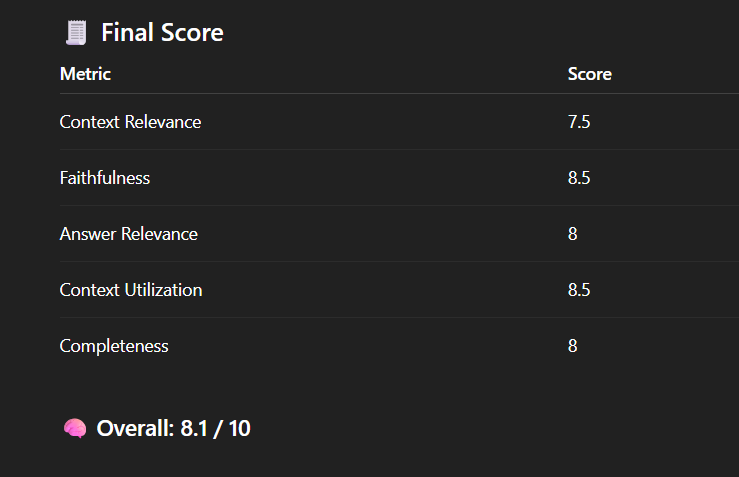